In [1]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/fraud-project/'

Mounted at /content/drive


In [2]:
!pip install shap -q

import shap
import pickle
import numpy as np
import matplotlib.pyplot as plt

with open(DRIVE_PATH + 'processed_data.pkl', 'rb') as f:
    data = pickle.load(f)
with open(DRIVE_PATH + 'best_model.pkl', 'rb') as f:
    best = pickle.load(f)

X_test = data['X_test']
model  = best['model']

print("Loaded!")

Loaded!


In [3]:
# Compute SHAP Values
print("Computing SHAP values... (5-10 mins)")

explainer   = shap.TreeExplainer(model)
X_sample    = X_test.iloc[:500]    # sample for speed
shap_values = explainer.shap_values(X_sample)

print("Done!")

Computing SHAP values... (5-10 mins)
Done!


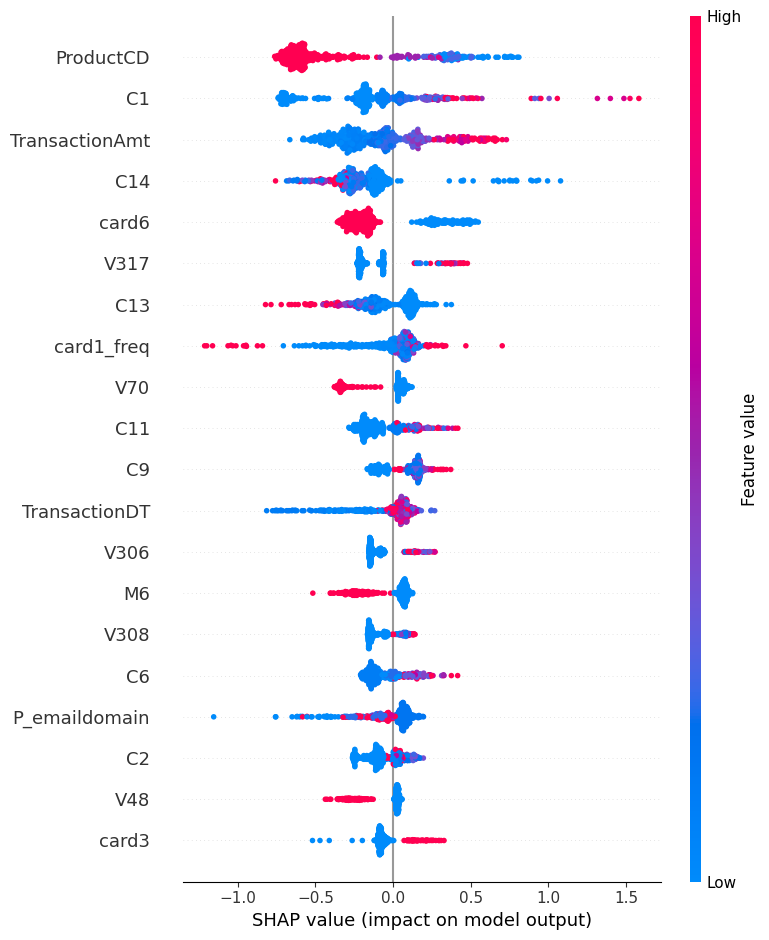

Saved!


In [4]:
# Summary Plot
plt.figure()
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

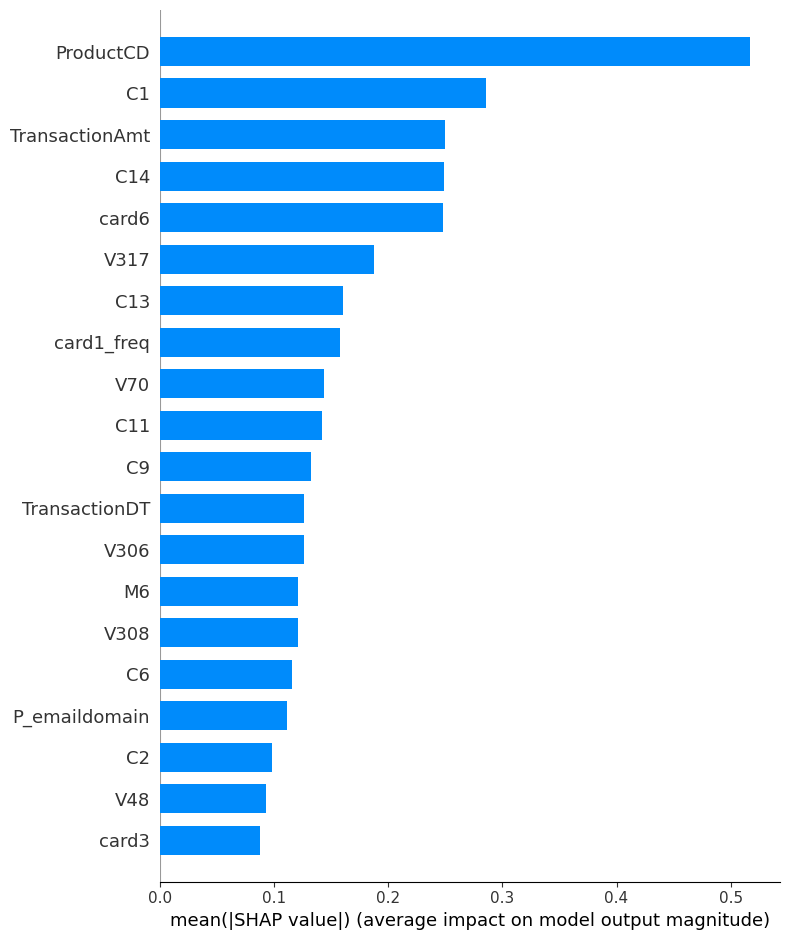

In [5]:
# Bar Plot
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

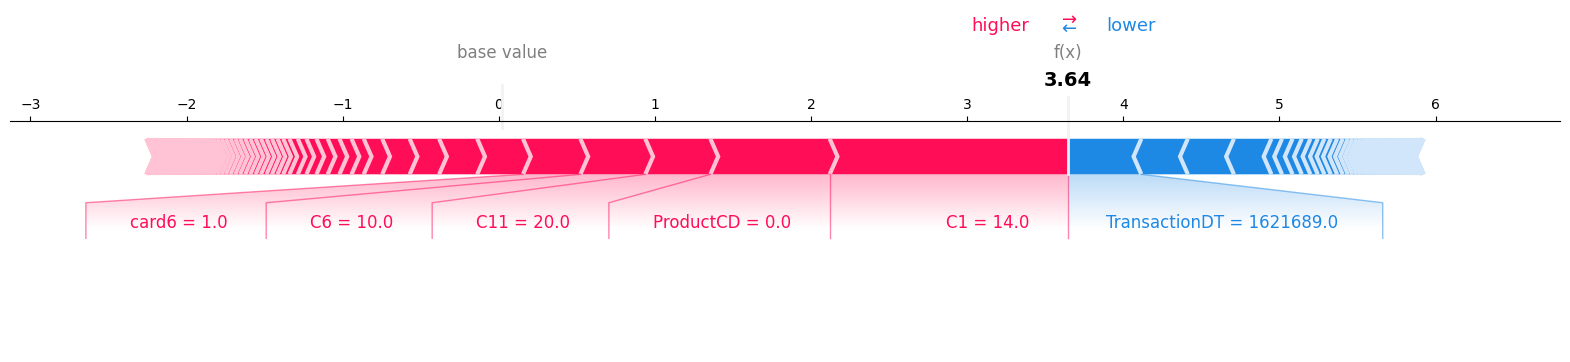

<Figure size 640x480 with 0 Axes>

SHAP complete! Move to Notebook 6 — API


In [6]:
# Explain one fraud prediction
idx = np.where(data['y_test'].values == 1)[0][0]

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_sample.iloc[idx],
    matplotlib=True
)
plt.tight_layout()
plt.savefig(DRIVE_PATH + 'shap_force.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP complete! Move to Notebook 6 — API")